In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import string
from textblob import TextBlob
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# =============================
# DATA LOADING
# =============================
train_df = pd.read_csv("../data/train_sample.csv")
test_df = pd.read_csv("../data/test_sample.csv")

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (1000, 2)
Test size: (1000, 2)


In [5]:
# --------------------------------
# 1. TF-IDF
# --------------------------------

vectorizer_tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    lowercase=True
)

X_train_tfidf = vectorizer_tfidf.fit_transform(train_df["review"])
X_test_tfidf = vectorizer_tfidf.transform(test_df["review"])

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (1000, 5000)
TF-IDF test shape: (1000, 5000)


In [7]:
# --------------------------------
# 2. Word2Vec
# --------------------------------

# Tokenisation
train_tokens = train_df["review"].apply(simple_preprocess)
test_tokens = test_df["review"].apply(simple_preprocess)

# Corpus complet (train + test pour meilleur vocabulaire)
corpus = pd.concat([train_tokens, test_tokens]).tolist()

print("Example tokens:", corpus[:2])

model = Word2Vec(
    sentences=corpus,
    vector_size=300,
    window=5,
    min_count=2,
    sg=1,
    workers=4
)

print("Vocabulary size:", len(model.wv))

Example tokens: [['stuning', 'even', 'for', 'the', 'non', 'gamer', 'this', 'sound', 'track', 'was', 'beautiful', 'it', 'paints', 'the', 'senery', 'in', 'your', 'mind', 'so', 'well', 'would', 'recomend', 'it', 'even', 'to', 'people', 'who', 'hate', 'vid', 'game', 'music', 'have', 'played', 'the', 'game', 'chrono', 'cross', 'but', 'out', 'of', 'all', 'of', 'the', 'games', 'have', 'ever', 'played', 'it', 'has', 'the', 'best', 'music', 'it', 'backs', 'away', 'from', 'crude', 'keyboarding', 'and', 'takes', 'fresher', 'step', 'with', 'grate', 'guitars', 'and', 'soulful', 'orchestras', 'it', 'would', 'impress', 'anyone', 'who', 'cares', 'to', 'listen'], ['the', 'best', 'soundtrack', 'ever', 'to', 'anything', 'reading', 'lot', 'of', 'reviews', 'saying', 'that', 'this', 'is', 'the', 'best', 'game', 'soundtrack', 'and', 'figured', 'that', 'write', 'review', 'to', 'disagree', 'bit', 'this', 'in', 'my', 'opinino', 'is', 'yasunori', 'mitsuda', 'ultimate', 'masterpiece', 'the', 'music', 'is', 'timel

In [8]:
# --------------------------------
# 3. Document Embeddings
# --------------------------------

def document_vector(tokens):
    words = [w for w in tokens if w in model.wv]

    if len(words) == 0:
        return np.zeros(model.vector_size)

    return np.mean(model.wv[words], axis=0)


# Création des embeddings
X_train_w2v = np.array([document_vector(tokens) for tokens in train_tokens])
X_test_w2v = np.array([document_vector(tokens) for tokens in test_tokens])

print("Word2Vec train shape:", X_train_w2v.shape)
print("Word2Vec test shape:", X_test_w2v.shape)

Word2Vec train shape: (1000, 300)
Word2Vec test shape: (1000, 300)


In [9]:
# --------------------------------
# 4. Analyse des similarités
# --------------------------------

print("\nMost similar words to 'good':")
try:
    print(model.wv.most_similar("good", topn=10))
except KeyError:
    print("Word 'good' not in vocabulary")

print("\nSimilarity between 'good' and 'great':")
try:
    print(model.wv.similarity("good", "great"))
except KeyError:
    print("Words not found in vocabulary")


Most similar words to 'good':
[('nice', 0.9335600137710571), ('disappointed', 0.9202327132225037), ('pretty', 0.9187373518943787), ('great', 0.9124860763549805), ('overall', 0.909113883972168), ('interesting', 0.9076436161994934), ('classic', 0.9067522883415222), ('informative', 0.904729425907135), ('entertaining', 0.9042301177978516), ('funny', 0.9034985899925232)]

Similarity between 'good' and 'great':
0.9124861


In [10]:
# --------------------------------
# . Features additionnelles (Longueur texte, Nombre mots uniques, Ratio ponctuation, Nombre majuscules, Sentiment lexicon score (TextBlob))
# --------------------------------
def extract_features(df):

    features = pd.DataFrame()

    features["text_length"] = df["review"].apply(len)
    features["num_unique_words"] = df["review"].apply(lambda x: len(set(x.split())))
    features["punctuation_ratio"] = df["review"].apply(
        lambda x: sum(c in string.punctuation for c in x) / max(len(x),1)
    )
    features["num_uppercase"] = df["review"].apply(
        lambda x: sum(1 for c in x if c.isupper())
    )
    features["sentiment"] = df["review"].apply(
        lambda x: TextBlob(x).sentiment.polarity
    )

    return features

X_train_extra = extract_features(train_df)
X_test_extra = extract_features(test_df)

print(X_train_extra.head())

   text_length  num_unique_words  punctuation_ratio  num_uppercase  sentiment
0          426                61           0.025822             10  -0.021875
1          509                73           0.027505             12   0.261111
2          760               101           0.052632             27   0.274691
3          743                87           0.044415             59   0.272727
4          481                71           0.045738             31   0.324802


Text(0.5, 1.0, 'Feature correlation matrix')

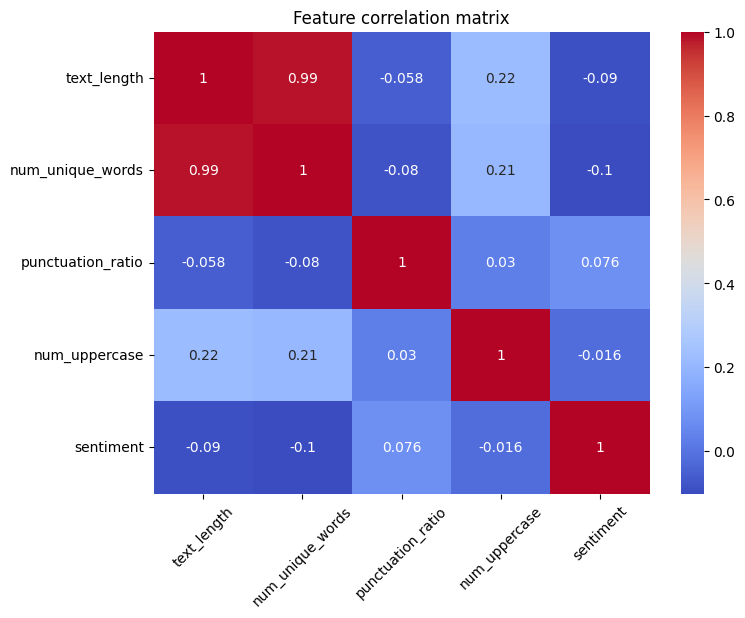

In [11]:
corr = X_train_extra.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.xticks(rotation=45, fontsize=10)
plt.title("Feature correlation matrix")